In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("smartphones_raw.csv")
df.head()

,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
0,"OPPO K14x 5G (Icy Blue, 128 GB)",OPPO,16999.0,17999.0,5.0,4.3,3075.0,198.0,4.0,128.0,50MP + 2MP,5MP; f/2.2; FOV 77°; 3P lens,6500.0
1,"Samsung M06 5G (Sage Green, 128 GB)",Samsung,12690.0,15499.0,18.0,4.1,1999.0,127.0,4.0,128.0,50MP Rear Camera,NaN,5000.0
2,"MOTOROLA g37 (PANTONE Impenetrable, 64 GB)",MOTOROLA,18999.0,24999.0,24.0,4.0,11.0,2.0,4.0,64.0,50MP Rear Camera,8MP Front Camera,5200.0
3,"Samsung M06 5G (Sage Green, 128 GB)",Samsung,14168.0,18999.0,25.0,4.1,1502.0,83.0,6.0,128.0,50MP Rear Camera,NaN,5000.0
4,"POCO C85x Charger in the Box (Emerald Green, 6...",POCO,12499.0,20999.0,40.0,4.1,1662.0,92.0,4.0,64.0,32MP Rear Camera,NaN,6300.0


In [5]:
# 1) Basic information
print("="*50)
print("SHAPE")
print(df.shape)

print("\n" + "="*50)
print("COLUMN NAMES")
print(df.columns.tolist())

print("\n" + "="*50)
print("DATA TYPES")
print(df.dtypes)

print("\n" + "="*50)
print("MISSING VALUES")
print(df.isnull().sum())

print("\n" + "="*50)
print("MISSING VALUE %")
print(round(df.isnull().mean()*100,2))

print("\n" + "="*50)
print("DUPLICATE ROWS")
print(df.duplicated().sum())

print("\n" + "="*50)
print("NUMERICAL SUMMARY")
print(df.describe())

print("\n" + "="*50)
print("UNIQUE VALUES COUNT")
print(df.nunique())

SHAPE
(984, 13)

COLUMN NAMES
['Product Name', 'Brand', 'Price', 'Original Price', 'Discount %', 'Rating', 'Ratings Count', 'Reviews Count', 'RAM (GB)', 'Storage (GB)', 'Rear Camera (MP)', 'Front Camera (MP)', 'Battery (mAh)']

DATA TYPES
Product Name          object
Brand                 object
Price                float64
Original Price       float64
Discount %           float64
Rating               float64
Ratings Count        float64
Reviews Count        float64
RAM (GB)             float64
Storage (GB)         float64
Rear Camera (MP)      object
Front Camera (MP)     object
Battery (mAh)        float64
dtype: object

MISSING VALUES
Product Name           0
Brand                  0
Price                  2
Original Price       238
Discount %           247
Rating                 4
Ratings Count          4
Reviews Count          4
RAM (GB)              33
Storage (GB)          36
Rear Camera (MP)       0
Front Camera (MP)    121
Battery (mAh)         33
dtype: int64

MISSING VALUE %

In [6]:
# Check duplicate product names

print("Duplicate Product Names:")
print(df["Product Name"].duplicated().sum())

Duplicate Product Names:
283


In [7]:
# Duplicate Analysis + Missing Value Investigation

# A) - Examine Duplicate Rows

# Total duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Display first few duplicates
duplicates = df[df.duplicated(keep=False)]

print("\nShape of duplicate records:")
print(duplicates.shape)

duplicates.head(20)

Duplicate Rows: 143

Shape of duplicate records:
(276, 13)


,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
4,"POCO C85x Charger in the Box (Emerald Green, 6...",POCO,12499.0,20999.0,40.0,4.1,1662.0,92.0,4.0,64.0,32MP Rear Camera,NaN,6300.0
7,"POCO C81x (Ice Blue, 64 GB)",POCO,10999.0,18999.0,42.0,3.8,92.0,6.0,3.0,64.0,13MP Rear Camera,8MP Front Camera,5200.0
10,"realme P4 5G (Steel Grey, 128 GB)",realme,21999.0,NaN,NaN,4.4,18347.0,1303.0,8.0,128.0,50MP + 8MP,16MP Front Camera,7000.0
15,"realme P4 Lite (Sea Blue, 128 GB)",realme,13999.0,NaN,NaN,4.1,2507.0,145.0,4.0,128.0,13MP Rear Camera,5MP Front Camera,6300.0
17,"MOTOROLA Edge 60 Fusion 5G (PANTONE Amazonite,...",MOTOROLA,22999.0,24999.0,8.0,4.4,120468.0,7120.0,8.0,128.0,50MP + 13MP,32MP Front Camera,5500.0
21,"POCO C85 5G Charger in the Box (Power Black, 1...",POCO,14499.0,20999.0,30.0,3.8,1112.0,111.0,4.0,128.0,50MP Rear Camera,8MP Front Camera,6000.0
22,"POCO C81x (Crystal Black, 64 GB)",POCO,10999.0,18999.0,42.0,3.8,92.0,6.0,3.0,64.0,13MP Rear Camera,8MP Front Camera,5200.0
23,"OnePlus Nord CE6 Lite (Hyper Black, 128 GB)",OnePlus,23715.0,31999.0,25.0,3.8,73.0,7.0,6.0,128.0,50MP Rear Camera,50MP Front Camera,7000.0
24,POCO C51 - Locked with Airtel Prepaid (Power B...,POCO,8499.0,9999.0,15.0,4.0,226809.0,12047.0,4.0,64.0,8MP Dual Rear Camera,5MP Front Camera,5000.0
25,"POCO C85 5G Charger in the Box (Power Black, 1...",POCO,14499.0,20999.0,30.0,3.8,1112.0,111.0,4.0,128.0,50MP Rear Camera,8MP Front Camera,6000.0


In [8]:
# B) - Check Missing Value Patterns

# Show rows where RAM is missing
print("RAM Missing:")
display(df[df["RAM (GB)"].isnull()].head())

# Show rows where Storage is missing
print("\nStorage Missing:")
display(df[df["Storage (GB)"].isnull()].head())

# Show rows where Battery is missing
print("\nBattery Missing:")
display(df[df["Battery (mAh)"].isnull()].head())

# Show rows where Front Camera is missing
print("\nFront Camera Missing:")
display(df[df["Front Camera (MP)"].isnull()].head())

RAM Missing:


,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
65,"Apple iPhone 15 (Black, 128 GB)",Apple,59900.0,NaN,NaN,4.6,245694.0,9251.0,NaN,NaN,48MP + 12MP,12MP Front Camera,NaN
126,"Apple iPhone 17 (Mist Blue, 256 GB)",Apple,82900.0,NaN,NaN,4.6,12927.0,821.0,NaN,NaN,48MP + 48MP,18MP Front Camera,NaN
136,"Apple iPhone 16 (White, 128 GB)",Apple,69900.0,NaN,NaN,4.6,193584.0,6827.0,NaN,NaN,48MP + 12MP,12MP Front Camera,NaN
139,"Apple iPhone 17 Pro (Cosmic Orange, 256 GB)",Apple,134900.0,NaN,NaN,4.7,1963.0,149.0,NaN,NaN,48MP + 48MP + 48MP,18MP Front Camera,NaN
165,"Apple iPhone 17 Pro (Silver, 256 GB)",Apple,134900.0,NaN,NaN,4.7,1963.0,149.0,NaN,NaN,48MP + 48MP + 48MP,18MP Front Camera,NaN



Storage Missing:


,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
65,"Apple iPhone 15 (Black, 128 GB)",Apple,59900.0,NaN,NaN,4.6,245694.0,9251.0,NaN,NaN,48MP + 12MP,12MP Front Camera,NaN
126,"Apple iPhone 17 (Mist Blue, 256 GB)",Apple,82900.0,NaN,NaN,4.6,12927.0,821.0,NaN,NaN,48MP + 48MP,18MP Front Camera,NaN
136,"Apple iPhone 16 (White, 128 GB)",Apple,69900.0,NaN,NaN,4.6,193584.0,6827.0,NaN,NaN,48MP + 12MP,12MP Front Camera,NaN
139,"Apple iPhone 17 Pro (Cosmic Orange, 256 GB)",Apple,134900.0,NaN,NaN,4.7,1963.0,149.0,NaN,NaN,48MP + 48MP + 48MP,18MP Front Camera,NaN
165,"Apple iPhone 17 Pro (Silver, 256 GB)",Apple,134900.0,NaN,NaN,4.7,1963.0,149.0,NaN,NaN,48MP + 48MP + 48MP,18MP Front Camera,NaN



Battery Missing:


,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
65,"Apple iPhone 15 (Black, 128 GB)",Apple,59900.0,NaN,NaN,4.6,245694.0,9251.0,NaN,NaN,48MP + 12MP,12MP Front Camera,NaN
126,"Apple iPhone 17 (Mist Blue, 256 GB)",Apple,82900.0,NaN,NaN,4.6,12927.0,821.0,NaN,NaN,48MP + 48MP,18MP Front Camera,NaN
136,"Apple iPhone 16 (White, 128 GB)",Apple,69900.0,NaN,NaN,4.6,193584.0,6827.0,NaN,NaN,48MP + 12MP,12MP Front Camera,NaN
139,"Apple iPhone 17 Pro (Cosmic Orange, 256 GB)",Apple,134900.0,NaN,NaN,4.7,1963.0,149.0,NaN,NaN,48MP + 48MP + 48MP,18MP Front Camera,NaN
165,"Apple iPhone 17 Pro (Silver, 256 GB)",Apple,134900.0,NaN,NaN,4.7,1963.0,149.0,NaN,NaN,48MP + 48MP + 48MP,18MP Front Camera,NaN



Front Camera Missing:


,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
1,"Samsung M06 5G (Sage Green, 128 GB)",Samsung,12690.0,15499.0,18.0,4.1,1999.0,127.0,4.0,128.0,50MP Rear Camera,NaN,5000.0
3,"Samsung M06 5G (Sage Green, 128 GB)",Samsung,14168.0,18999.0,25.0,4.1,1502.0,83.0,6.0,128.0,50MP Rear Camera,NaN,5000.0
4,"POCO C85x Charger in the Box (Emerald Green, 6...",POCO,12499.0,20999.0,40.0,4.1,1662.0,92.0,4.0,64.0,32MP Rear Camera,NaN,6300.0
5,"POCO C85x Charger in the Box (Sunset Gold, 64 GB)",POCO,12499.0,20999.0,40.0,4.1,1662.0,92.0,4.0,64.0,32MP Rear Camera,NaN,6300.0
14,"POCO M7 Plus 5G (Carbon Black, 128 GB)",POCO,15999.0,16999.0,5.0,4.3,8946.0,563.0,6.0,128.0,50MP AI Dual Camera,NaN,7000.0


In [9]:
# C) - Check Brand Consistency

print("Brands Found:\n")
print(sorted(df["Brand"].unique()))

Brands Found:

['Ai+', 'Alcatel', 'Apple', 'CMF', 'Google', 'I', 'IQOO', 'Infinix', 'LAVA', 'Lenovo', 'MOTOROLA', 'Motorola', 'Nothing', 'OPPO', 'OnePlus', 'POCO', 'REDMI', 'Samsung', 'Tecno', 'Vivo', 'realme', 'vivo']


In [11]:
# D) - Investigate Storage = 0
df[df["Storage (GB)"] == 0]

,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
60,"realme C85 5G (Parrot Purple, 128.0 GB)",realme,21999.0,24999.0,12.0,4.3,190.0,12.0,4.0,0.0,50MP Rear Camera,8MP Front Camera,7000.0
75,"realme C85 5G (Peacock Green, 128.0 GB)",realme,16499.0,NaN,NaN,4.3,190.0,12.0,4.0,0.0,50MP Rear Camera,8MP Front Camera,7000.0
77,"realme C85 5G (Parrot Purple, 128.0 GB)",realme,16499.0,NaN,NaN,4.3,190.0,12.0,4.0,0.0,50MP Rear Camera,8MP Front Camera,7000.0
399,"realme C85 5G (Peacock Green, 128.0 GB)",realme,16499.0,NaN,NaN,4.3,190.0,12.0,4.0,0.0,50MP Rear Camera,8MP Front Camera,7000.0
522,"realme C85 5G (Parrot Purple, 128.0 GB)",realme,16499.0,NaN,NaN,4.3,190.0,12.0,4.0,0.0,50MP Rear Camera,8MP Front Camera,7000.0
554,"realme C85 5G (Parrot Purple, 128.0 GB)",realme,21999.0,24999.0,12.0,4.3,190.0,12.0,4.0,0.0,50MP Rear Camera,8MP Front Camera,7000.0


In [12]:
# E) - Investigate Extreme Battery Values
print(df["Battery (mAh)"].value_counts().sort_index())

Battery (mAh)
3900.0       1
4000.0      14
4300.0       7
4400.0       1
4410.0       2
4500.0       5
4900.0       7
4970.0       2
5000.0     272
5010.0       6
5030.0       3
5100.0       5
5110.0       2
5160.0      22
5200.0      33
5400.0      15
5500.0      38
5520.0      14
5700.0       8
5800.0       6
5850.0       3
6000.0     107
6200.0       8
6300.0      30
6500.0      92
6510.0       2
6550.0       1
6800.0       1
7000.0     170
7200.0      10
7300.0       4
7400.0       2
7550.0       6
7600.0       7
8000.0      22
9000.0       8
9020.0       4
10001.0     11
Name: count, dtype: int64


In [14]:
# 2) - Perform Safe Cleaning

# Create a copy
df_clean = df.copy()


# 1. Remove exact duplicates
print("Rows before:", df_clean.shape[0])
df_clean = df_clean.drop_duplicates()
print("Rows after:", df_clean.shape[0])


# 2. Standardize Brand Names
df_clean["Brand"] = df_clean["Brand"].replace({
    "Motorola": "MOTOROLA",
    "vivo": "Vivo"
})


# 3. Strip extra spaces
df_clean["Brand"] = df_clean["Brand"].str.strip()
df_clean["Product Name"] = df_clean["Product Name"].str.strip()


# 4. Verify changes
print("\nRemaining duplicates:")
print(df_clean.duplicated().sum())

print("\nBrands:")
print(sorted(df_clean["Brand"].unique()))

Rows before: 984
Rows after: 841

Remaining duplicates:
0

Brands:
['Ai+', 'Alcatel', 'Apple', 'CMF', 'Google', 'I', 'IQOO', 'Infinix', 'LAVA', 'Lenovo', 'MOTOROLA', 'Nothing', 'OPPO', 'OnePlus', 'POCO', 'REDMI', 'Samsung', 'Tecno', 'Vivo', 'realme']


In [15]:
print(df_clean.shape)

print("\nMissing Values After Step 3:\n")
print(df_clean.isnull().sum())

(841, 13)

Missing Values After Step 3:

Product Name           0
Brand                  0
Price                  2
Original Price       196
Discount %           205
Rating                 3
Ratings Count          3
Reviews Count          3
RAM (GB)              30
Storage (GB)          32
Rear Camera (MP)       0
Front Camera (MP)    107
Battery (mAh)         30
dtype: int64


In [16]:
# Inspect Battery = 10001
df_clean[df_clean["Battery (mAh)"] == 10001]

,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
659,"realme P4 Power 5G (TransSilver, 128 GB)",realme,29499.0,32999.0,10.0,4.5,4920.0,461.0,8.0,128.0,50MP + 8MP,Yes,10001.0
682,"realme P4 Power 5G (TransSilver, 256 GB)",realme,31499.0,34999.0,10.0,4.5,4920.0,461.0,8.0,256.0,50MP + 8MP,Yes,10001.0
690,"realme P4 Power 5G (TransBlue, 128 GB)",realme,29499.0,32999.0,10.0,4.5,4920.0,461.0,8.0,128.0,50MP + 8MP,Yes,10001.0
699,"realme P4 Power 5G (TransBlue, 256 GB)",realme,31499.0,34999.0,10.0,4.5,4920.0,461.0,8.0,256.0,50MP + 8MP,Yes,10001.0
700,"realme P4 Power 5G (TransSilver, 256 GB)",realme,34499.0,37999.0,9.0,4.4,1236.0,161.0,12.0,256.0,50MP + 8MP,Yes,10001.0
710,"realme P4 Power 5G (TransOrange, 256 GB)",realme,31499.0,34999.0,10.0,4.5,4920.0,461.0,8.0,256.0,50MP + 8MP,Yes,10001.0
720,"realme P4 Power 5G (TransOrange, 128 GB)",realme,29499.0,32999.0,10.0,4.5,4920.0,461.0,8.0,128.0,50MP + 8MP,Yes,10001.0
744,"realme Narzo Power 5G (Titan Blue, 256 GB)",realme,28993.0,37999.0,23.0,3.8,20.0,2.0,8.0,256.0,50MP Rear Camera,NaN,10001.0
749,"realme Narzo Power 5G (Titan Blue, 128 GB)",realme,24193.0,35999.0,32.0,3.8,20.0,2.0,8.0,128.0,50MP Rear Camera,NaN,10001.0
761,"realme Narzo Power 5G (Titan Silver, 256 GB)",realme,29894.0,37999.0,21.0,3.8,20.0,2.0,8.0,256.0,50MP Rear Camera,NaN,10001.0


In [17]:
# 3) - Investigate Recoverable Information

# A) - Check Missing RAM Phones
ram_missing = df_clean[df_clean["RAM (GB)"].isnull()]

print("RAM Missing Count:", len(ram_missing))

ram_missing[["Product Name","Brand","RAM (GB)","Storage (GB)","Battery (mAh)"]].head(30)

RAM Missing Count: 30


,Product Name,Brand,RAM (GB),Storage (GB),Battery (mAh)
65,"Apple iPhone 15 (Black, 128 GB)",Apple,NaN,NaN,NaN
126,"Apple iPhone 17 (Mist Blue, 256 GB)",Apple,NaN,NaN,NaN
136,"Apple iPhone 16 (White, 128 GB)",Apple,NaN,NaN,NaN
139,"Apple iPhone 17 Pro (Cosmic Orange, 256 GB)",Apple,NaN,NaN,NaN
165,"Apple iPhone 17 Pro (Silver, 256 GB)",Apple,NaN,NaN,NaN
177,"Apple iPhone 16 (Pink, 128 GB)",Apple,NaN,NaN,NaN
180,"Apple iPhone 16 (Black, 128 GB)",Apple,NaN,NaN,NaN
221,"Apple iPhone 16 (Ultramarine, 128 GB)",Apple,NaN,NaN,NaN
238,"Apple iPhone 16 Plus (Teal, 128 GB)",Apple,NaN,NaN,NaN
304,"Apple iPhone 14 (Blue, 128 GB)",Apple,NaN,NaN,NaN


In [18]:
# B) - Check Missing Storage Phones
storage_missing = df_clean[df_clean["Storage (GB)"].isnull()]

print("Storage Missing Count:", len(storage_missing))

storage_missing[["Product Name","Brand","RAM (GB)","Storage (GB)"]].head(30)

Storage Missing Count: 32


,Product Name,Brand,RAM (GB),Storage (GB)
65,"Apple iPhone 15 (Black, 128 GB)",Apple,NaN,NaN
126,"Apple iPhone 17 (Mist Blue, 256 GB)",Apple,NaN,NaN
136,"Apple iPhone 16 (White, 128 GB)",Apple,NaN,NaN
139,"Apple iPhone 17 Pro (Cosmic Orange, 256 GB)",Apple,NaN,NaN
165,"Apple iPhone 17 Pro (Silver, 256 GB)",Apple,NaN,NaN
177,"Apple iPhone 16 (Pink, 128 GB)",Apple,NaN,NaN
180,"Apple iPhone 16 (Black, 128 GB)",Apple,NaN,NaN
221,"Apple iPhone 16 (Ultramarine, 128 GB)",Apple,NaN,NaN
238,"Apple iPhone 16 Plus (Teal, 128 GB)",Apple,NaN,NaN
260,"MOTOROLA Signature (PANTONE Carbon, 1 TB)",MOTOROLA,16.0,NaN


In [19]:
# C) - Check Missing Battery Phones
battery_missing = df_clean[df_clean["Battery (mAh)"].isnull()]

print("Battery Missing Count:", len(battery_missing))

battery_missing[["Product Name","Brand","Battery (mAh)"]].head(30)

Battery Missing Count: 30


,Product Name,Brand,Battery (mAh)
65,"Apple iPhone 15 (Black, 128 GB)",Apple,NaN
126,"Apple iPhone 17 (Mist Blue, 256 GB)",Apple,NaN
136,"Apple iPhone 16 (White, 128 GB)",Apple,NaN
139,"Apple iPhone 17 Pro (Cosmic Orange, 256 GB)",Apple,NaN
165,"Apple iPhone 17 Pro (Silver, 256 GB)",Apple,NaN
177,"Apple iPhone 16 (Pink, 128 GB)",Apple,NaN
180,"Apple iPhone 16 (Black, 128 GB)",Apple,NaN
221,"Apple iPhone 16 (Ultramarine, 128 GB)",Apple,NaN
238,"Apple iPhone 16 Plus (Teal, 128 GB)",Apple,NaN
304,"Apple iPhone 14 (Blue, 128 GB)",Apple,NaN


In [20]:
# D) - Investigate Missing Front Camera Values
front_missing = df_clean[df_clean["Front Camera (MP)"].isnull()]

print("Front Camera Missing Count:", len(front_missing))

front_missing[[
    "Product Name",
    "Brand",
    "Rear Camera (MP)",
    "Front Camera (MP)"
]].head(50)

Front Camera Missing Count: 107


,Product Name,Brand,Rear Camera (MP),Front Camera (MP)
1,"Samsung M06 5G (Sage Green, 128 GB)",Samsung,50MP Rear Camera,NaN
3,"Samsung M06 5G (Sage Green, 128 GB)",Samsung,50MP Rear Camera,NaN
4,"POCO C85x Charger in the Box (Emerald Green, 6...",POCO,32MP Rear Camera,NaN
5,"POCO C85x Charger in the Box (Sunset Gold, 64 GB)",POCO,32MP Rear Camera,NaN
14,"POCO M7 Plus 5G (Carbon Black, 128 GB)",POCO,50MP AI Dual Camera,NaN
40,"POCO M7 Plus 5G (Carbon Black, 128 GB)",POCO,50MP AI Dual Camera,NaN
41,"POCO C85x Charger in the Box (Elite Black, 64 GB)",POCO,32MP Rear Camera,NaN
49,"POCO M7 Plus 5G (Chrome Silver, 128 GB)",POCO,50MP AI Dual Camera,NaN
72,"POCO M7 Plus 5G (Chrome Silver, 128 GB)",POCO,50MP AI Dual Camera,NaN
73,"Samsung M05 (Mint Green, 64 GB)",Samsung,50MP Rear Camera,NaN


In [21]:
# E) - Find Weird Values in Front Camera Column
print(df_clean["Front Camera (MP)"].unique())

['5MP; f/2.2; FOV 77°; 3P lens' nan '8MP Front Camera' '32MP Front Camera'
 '16MP Front Camera' '5MP Front Camera' '20MP Front Camera'
 '50MP Front Camera' '13MP Front Camera' '12MP Front Camera'
 '2MP Front Camera' '18MP Front Camera' '12MP + 2MP Dual Front Camera'
 'Yes' '2MP + 2MP Dual Front Camera' 'A19 chip, 6 Core'
 '32MP + 32MP Dual Front Camera' '10.5MP Front Camera'
 '5MP + 5MP Dual Front Camera' '20MP + 32MP Dual Front Camera'
 '0MP Front Camera']


In [22]:
# F) - Find Weird Text Values in Camera Columns
print("Rear Camera Sample Values:")
print(df_clean["Rear Camera (MP)"].value_counts().head(30))

print("\n\nFront Camera Sample Values:")
print(df_clean["Front Camera (MP)"].value_counts(dropna=False).head(30))

Rear Camera Sample Values:
Rear Camera (MP)
50MP Rear Camera        179
50MP + 2MP              151
50MP + 8MP               70
50MP + 50MP + 8MP        42
13MP Rear Camera         38
32MP Rear Camera         30
50MP + 13MP              25
8MP Rear Camera          18
50MP + 50MP              16
50MP + 8MP + 2MP         15
50MP + 5MP + 2MP         14
50MP + 50MP + 50MP       14
48MP + 12MP              13
50MP + 12MP              12
50MP + 50MP + 10MP       10
108MP Rear Camera        10
50MP + AI Lens            9
50MP + 0.08MP             8
50MP + 10MP + 12MP        8
200MP + 50MP              8
50MP (OIS) + 2MP          8
200MP + 8MP               7
50MP + 8MP + 50MP         7
200MP Rear Camera         6
64MP + 8MP                6
200MP + 50MP + 50MP       6
50MP + AI Lens + 2MP      5
50MP AI Dual Camera       5
108MP + 8MP + 2MP         5
16MP Rear Camera          5
Name: count, dtype: int64


Front Camera Sample Values:
Front Camera (MP)
8MP Front Camera                 160
NaN  

In [23]:
# 4) - Recover Storage + Fix Obvious Errors

import numpy as np
import re

# 1. Extract Storage from Product Name
def extract_storage(name):
    
    # Match 128 GB, 256 GB, 512 GB etc.
    gb_match = re.search(r'(\d+)\s*GB', str(name))
    
    if gb_match:
        return float(gb_match.group(1))
    
    # Match 1 TB
    tb_match = re.search(r'(\d+)\s*TB', str(name))
    
    if tb_match:
        return float(tb_match.group(1)) * 1024
        
    return np.nan

extracted_storage = df_clean["Product Name"].apply(extract_storage)

# Fill missing storage
df_clean["Storage (GB)"] = df_clean["Storage (GB)"].fillna(extracted_storage)

# Fix storage = 0

mask = df_clean["Storage (GB)"] == 0
df_clean.loc[mask, "Storage (GB)"] = extracted_storage[mask]



# 2. Replace Front Camera Garbage Values
bad_front_values = [
    "Yes",
    "A19 chip, 6 Core"
]

df_clean["Front Camera (MP)"] = df_clean["Front Camera (MP)"].replace(
    bad_front_values,
    np.nan
)


# 3. Replace Battery = 10001
df_clean.loc[
    df_clean["Battery (mAh)"] == 10001,
    "Battery (mAh)"
] = np.nan



# 4. Check Results
print("Missing Storage:")
print(df_clean["Storage (GB)"].isnull().sum())

print("\nStorage = 0 Count:")
print((df_clean["Storage (GB)"] == 0).sum())

print("\nFront Camera Missing:")
print(df_clean["Front Camera (MP)"].isnull().sum())

print("\nBattery Missing:")
print(df_clean["Battery (mAh)"].isnull().sum())

Missing Storage:
0

Storage = 0 Count:
3

Front Camera Missing:
142

Battery Missing:
41


In [24]:
print("\nRows with Storage still missing:")
display(
    df_clean[df_clean["Storage (GB)"].isnull()][
        ["Product Name","Brand","Storage (GB)"]
    ]
)


Rows with Storage still missing:


,Product Name,Brand,Storage (GB)


In [25]:
print("\nUnique Front Camera Values")

print(
    sorted(
        [str(x) for x in df_clean["Front Camera (MP)"].dropna().unique()]
    )
)


Unique Front Camera Values
['0MP Front Camera', '10.5MP Front Camera', '12MP + 2MP Dual Front Camera', '12MP Front Camera', '13MP Front Camera', '16MP Front Camera', '18MP Front Camera', '20MP + 32MP Dual Front Camera', '20MP Front Camera', '2MP + 2MP Dual Front Camera', '2MP Front Camera', '32MP + 32MP Dual Front Camera', '32MP Front Camera', '50MP Front Camera', '5MP + 5MP Dual Front Camera', '5MP Front Camera', '5MP; f/2.2; FOV 77°; 3P lens', '8MP Front Camera']


In [26]:
# 5) - Investigate Remaining Data Issues

# A. Find Storage = 0 Records
df_clean[df_clean["Storage (GB)"] == 0][
    [
        "Product Name",
        "Brand",
        "RAM (GB)",
        "Storage (GB)"
    ]
]

,Product Name,Brand,RAM (GB),Storage (GB)
60,"realme C85 5G (Parrot Purple, 128.0 GB)",realme,4.0,0.0
75,"realme C85 5G (Peacock Green, 128.0 GB)",realme,4.0,0.0
77,"realme C85 5G (Parrot Purple, 128.0 GB)",realme,4.0,0.0


In [27]:
# B. Investigate Missing Price
df_clean[df_clean["Price"].isnull()]

,Product Name,Brand,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Rear Camera (MP),Front Camera (MP),Battery (mAh)
439,"Motorola e13 (Aurora Green, 128 GB)",MOTOROLA,NaN,NaN,NaN,4.1,36029.0,1985.0,8.0,128.0,13MP Rear Camera,5MP Front Camera,5000.0
441,"OnePlus Nord CE 3 Lite 5G (Pastel Lime, 128 GB)",OnePlus,NaN,NaN,NaN,4.4,168541.0,8494.0,8.0,128.0,108MP Rear Camera,NaN,5000.0


In [28]:
# C. Investigate Missing Ratings
df_clean[
    df_clean["Rating"].isnull()
][
    [
        "Product Name",
        "Brand",
        "Rating",
        "Ratings Count",
        "Reviews Count"
    ]
]

,Product Name,Brand,Rating,Ratings Count,Reviews Count
64,"MOTOROLA g37 power (PANTONE Impenetrable, 128 GB)",MOTOROLA,NaN,NaN,NaN
706,"MOTOROLA g37 power (PANTONE Nautical Blue, 128...",MOTOROLA,NaN,NaN,NaN
867,"MOTOROLA g37 power (PANTONE Capri, 128 GB)",MOTOROLA,NaN,NaN,NaN


In [29]:
# D. Check Apple Models
print("RAM Missing by Brand")
print(
    df_clean[df_clean["RAM (GB)"].isnull()]
    ["Brand"]
    .value_counts()
)

print("\nBattery Missing by Brand")
print(
    df_clean[df_clean["Battery (mAh)"].isnull()]
    ["Brand"]
    .value_counts()
)

RAM Missing by Brand
Brand
Apple    30
Name: count, dtype: int64

Battery Missing by Brand
Brand
Apple     30
realme    11
Name: count, dtype: int64


In [30]:
# E. Investigate Weird Front Camera Values
df_clean[
    df_clean["Front Camera (MP)"]
    .astype(str)
    .str.contains(";|0MP", regex=True, na=False)
][
    [
        "Product Name",
        "Brand",
        "Front Camera (MP)"
    ]
]

,Product Name,Brand,Front Camera (MP)
0,"OPPO K14x 5G (Icy Blue, 128 GB)",OPPO,5MP; f/2.2; FOV 77°; 3P lens
8,"OPPO K14x 5G (Prism Violet, 128 GB)",OPPO,5MP; f/2.2; FOV 77°; 3P lens
18,"OPPO K14x 5G (Icy Blue, 64 GB)",OPPO,5MP; f/2.2; FOV 77°; 3P lens
20,"POCO M8 Charger in the Box (Frost Silver, 128 GB)",POCO,20MP Front Camera
23,"OnePlus Nord CE6 Lite (Hyper Black, 128 GB)",OnePlus,50MP Front Camera
...,...,...,...
959,"OPPO F33 Pro 5G (Passion Red, 128 GB)",OPPO,50MP Front Camera
960,"REDMI Note 14 Pro 5G (Phantom Purple, 256 GB)",REDMI,20MP Front Camera
961,"POCO M8 Charger in the Box (Glacial Blue, 256 GB)",POCO,20MP Front Camera
970,"OPPO Reno14 Pro 5G (Pearl White, 256 GB)",OPPO,50MP Front Camera


In [31]:
# 6) - Fix Remaining Obvious Issues

import numpy as np
import re

# 1. Fix remaining storage=0 rows
def extract_storage_v2(name):

    # handles 128 GB
    match1 = re.search(r'(\d+(?:\.\d+)?)\s*GB', str(name))

    if match1:
        return float(match1.group(1))

    # handles 1 TB
    match2 = re.search(r'(\d+(?:\.\d+)?)\s*TB', str(name))

    if match2:
        return float(match2.group(1)) * 1024

    return np.nan


mask = df_clean["Storage (GB)"] == 0

df_clean.loc[mask, "Storage (GB)"] = (
    df_clean.loc[mask, "Product Name"]
    .apply(extract_storage_v2)
)



# 2. Fix OPPO front camera values
df_clean["Front Camera (MP)"] = (
    df_clean["Front Camera (MP)"]
    .replace(
        "5MP; f/2.2; FOV 77°; 3P lens",
        "5MP Front Camera"
    )
)



# 3. Check results
print("Storage=0 Count")
print((df_clean["Storage (GB)"] == 0).sum())

print("\nStorage Missing")
print(df_clean["Storage (GB)"].isnull().sum())

print("\nFront Camera Missing")
print(df_clean["Front Camera (MP)"].isnull().sum())

Storage=0 Count
0

Storage Missing
0

Front Camera Missing
142


In [32]:
# 7) - Check Remaining Missing Values
print(df_clean.isnull().sum().sort_values(ascending=False))

Discount %           205
Original Price       196
Front Camera (MP)    142
Battery (mAh)         41
RAM (GB)              30
Rating                 3
Ratings Count          3
Reviews Count          3
Price                  2
Product Name           0
Brand                  0
Storage (GB)           0
Rear Camera (MP)       0
dtype: int64


In [33]:
# 8) - Recover Original Price & Discount %

import numpy as np

# Recover Original Price
mask = (
    df_clean["Original Price"].isnull()
    &
    df_clean["Price"].notnull()
    &
    df_clean["Discount %"].notnull()
)

df_clean.loc[mask, "Original Price"] = (
    df_clean.loc[mask, "Price"] /
    (1 - df_clean.loc[mask, "Discount %"]/100)
)



# Recover Discount %
mask = (
    df_clean["Discount %"].isnull()
    &
    df_clean["Price"].notnull()
    &
    df_clean["Original Price"].notnull()
)

df_clean.loc[mask, "Discount %"] = (
    (
        df_clean.loc[mask, "Original Price"]
        -
        df_clean.loc[mask, "Price"]
    )
    /
    df_clean.loc[mask, "Original Price"]
    * 100
)


# Round values
df_clean["Original Price"] = (
    df_clean["Original Price"]
    .round(0)
)

df_clean["Discount %"] = (
    df_clean["Discount %"]
    .round(2)
)

print(df_clean[["Original Price","Discount %"]].isnull().sum())

Original Price    196
Discount %        196
dtype: int64


In [34]:
# 9) - Extract Numerical Camera Features

import re
import numpy as np

# Rear Camera Main MP
def rear_main_mp(text):

    nums = re.findall(r'(\d+(?:\.\d+)?)MP', str(text))

    if len(nums) > 0:
        return float(nums[0])

    return np.nan


# Front Camera MP
def front_mp(text):

    nums = re.findall(r'(\d+(?:\.\d+)?)MP', str(text))

    if len(nums) > 0:
        return float(nums[0])

    return np.nan


# Rear Camera Count
def rear_camera_count(text):

    nums = re.findall(r'(\d+(?:\.\d+)?)MP', str(text))

    return len(nums)


df_clean["Rear_Main_MP"] = (
    df_clean["Rear Camera (MP)"]
    .apply(rear_main_mp)
)

df_clean["Front_MP"] = (
    df_clean["Front Camera (MP)"]
    .apply(front_mp)
)

df_clean["Rear_Camera_Count"] = (
    df_clean["Rear Camera (MP)"]
    .apply(rear_camera_count)
)

print(df_clean[
    [
        "Rear_Main_MP",
        "Front_MP",
        "Rear_Camera_Count"
    ]
].head())

   Rear_Main_MP  Front_MP  Rear_Camera_Count
0          50.0       5.0                  2
1          50.0       NaN                  1
2          50.0       8.0                  1
3          50.0       NaN                  1
4          32.0       NaN                  1


In [35]:
# 10) - Create EDA Dataset
df_eda = df_clean.copy()

print(df_eda.shape)

print(df_eda.isnull().sum())

(841, 16)
Product Name           0
Brand                  0
Price                  2
Original Price       196
Discount %           196
Rating                 3
Ratings Count          3
Reviews Count          3
RAM (GB)              30
Storage (GB)           0
Rear Camera (MP)       0
Front Camera (MP)    142
Battery (mAh)         41
Rear_Main_MP           0
Front_MP             142
Rear_Camera_Count      0
dtype: int64


In [36]:
apple_df = df_clean[df_clean["Brand"] == "Apple"]
print(apple_df["Product Name"].unique())

['Apple iPhone 15 (Black, 128 GB)' 'Apple iPhone 17 (Mist Blue, 256 GB)'
 'Apple iPhone 16 (White, 128 GB)'
 'Apple iPhone 17 Pro (Cosmic Orange, 256 GB)'
 'Apple iPhone 17 Pro (Silver, 256 GB)' 'Apple iPhone 16 (Pink, 128 GB)'
 'Apple iPhone 16 (Black, 128 GB)' 'Apple iPhone 16 (Ultramarine, 128 GB)'
 'Apple iPhone 16 Plus (Teal, 128 GB)' 'Apple iPhone 14 (Blue, 128 GB)'
 'Apple iPhone 14 (Starlight, 128 GB)' 'Apple iPhone 14 (Purple, 128 GB)'
 'Apple iPhone 15 (Pink, 128 GB)' 'Apple iPhone 16 (Teal, 128 GB)'
 'Apple iPhone 17e (Black, 256 GB)'
 'Apple iPhone 16 Plus (Ultramarine, 128 GB)'
 'Apple iPhone 17 Pro (Deep Blue, 256 GB)'
 'Apple iPhone 16 Plus (White, 128 GB)' 'Apple iPhone 17e (White, 256 GB)'
 'Apple iPhone 16 Plus (Black, 256 GB)'
 'Apple iPhone 17 Pro (Cosmic Orange, 512 GB)'
 'Apple iPhone 17 (Black, 512 GB)' 'Apple iPhone 16 Plus (White, 256 GB)'
 'Apple iPhone 17e (Soft Pink, 256 GB)' 'Apple iPhone 17 (Sage, 512 GB)'
 'Apple iPhone Air (Sky Blue, 256 GB)'
 'Apple iPh

In [37]:
print(df_clean["RAM (GB)"].value_counts().sort_index())
print("\n")
print(df_clean["Battery (mAh)"].value_counts().sort_index())

RAM (GB)
3.0       8
4.0     187
6.0     131
8.0     339
12.0    133
16.0     13
Name: count, dtype: int64


Battery (mAh)
3900.0      1
4000.0     13
4300.0      7
4400.0      1
4410.0      2
4500.0      4
4900.0      6
4970.0      2
5000.0    235
5010.0      4
5030.0      2
5100.0      4
5110.0      2
5160.0     16
5200.0     26
5400.0     13
5500.0     32
5520.0     12
5700.0      8
5800.0      6
5850.0      3
6000.0     94
6200.0      8
6300.0     22
6500.0     78
6510.0      2
6550.0      1
6800.0      1
7000.0    143
7200.0     10
7300.0      4
7400.0      2
7550.0      4
7600.0      6
8000.0     16
9000.0      6
9020.0      4
Name: count, dtype: int64


In [43]:
# 11) - Feature Engineering

# Price per GB Storage
df_clean["Price_per_GB"] = (
    df_clean["Price"] /
    df_clean["Storage (GB)"]
)

# Budget Segmentation
def phone_segment(price):

    if pd.isna(price):
        return np.nan

    if price < 15000:
        return "Budget"

    elif price < 30000:
        return "Midrange"

    elif price < 50000:
        return "Upper Midrange"

    else:
        return "Premium"


df_clean["Price_Segment"] = (
    df_clean["Price"]
    .apply(phone_segment)
)


# Value Score
df_clean["Value_Score"] = (
    df_clean["Rating"]
    *
    np.log1p(df_clean["Ratings Count"])
)

print(df_clean[
    [
        "Price",
        "Storage (GB)",
        "Price_per_GB",
        "Price_Segment",
        "Value_Score"
    ]
].head())

     Price  Storage (GB)  Price_per_GB Price_Segment  Value_Score
0  16999.0         128.0    132.804688      Midrange    34.534957
1  12690.0         128.0     99.140625        Budget    31.163700
2  18999.0          64.0    296.859375      Midrange     9.939627
3  14168.0         128.0    110.687500        Budget    29.992395
4  12499.0          64.0    195.296875        Budget    30.407152


In [44]:
# Check Correlation
numeric_cols = df_clean.select_dtypes(include=np.number)
print(numeric_cols.columns)

Index(['Price', 'Original Price', 'Discount %', 'Rating', 'Ratings Count',
       'Reviews Count', 'RAM (GB)', 'Storage (GB)', 'Battery (mAh)',
       'Rear_Main_MP', 'Front_MP', 'Rear_Camera_Count', 'Price_per_GB',
       'Value_Score'],
      dtype='object')


In [45]:
numeric_cols.corr(numeric_only=True)

,Price,Original Price,Discount %,Rating,Ratings Count,Reviews Count,RAM (GB),Storage (GB),Battery (mAh),Rear_Main_MP,Front_MP,Rear_Camera_Count,Price_per_GB,Value_Score
Price,1.000000,0.968496,-0.168717,0.429641,-0.209566,-0.224253,0.710081,0.659833,0.080809,0.407046,0.261426,0.411641,0.624462,-0.194035
Original Price,0.968496,1.000000,0.048474,0.218726,-0.305558,-0.287372,0.710581,0.683831,0.292602,0.318398,0.453980,0.434963,0.478358,-0.341233
Discount %,-0.168717,0.048474,1.000000,-0.294363,0.053287,0.050747,-0.227656,-0.198436,0.001637,-0.218852,-0.142603,-0.055475,0.048285,-0.101289
Rating,0.429641,0.218726,-0.294363,1.000000,0.027023,0.028243,0.400179,0.350579,-0.058916,0.185587,0.187620,0.288783,0.249196,0.305912
Ratings Count,-0.209566,-0.305558,0.053287,0.027023,1.000000,0.972239,-0.235781,-0.235305,-0.335425,-0.122548,-0.180201,-0.041295,-0.047609,0.686916
Reviews Count,-0.224253,-0.287372,0.050747,0.028243,0.972239,1.000000,-0.202727,-0.218068,-0.340831,-0.115539,-0.137762,-0.004610,-0.096210,0.703173
RAM (GB),0.710081,0.710581,-0.227656,0.400179,-0.235781,-0.202727,1.000000,0.774594,0.192716,0.364080,0.560074,0.457338,0.208584,-0.157337
Storage (GB),0.659833,0.683831,-0.198436,0.350579,-0.235305,-0.218068,0.774594,1.000000,0.198841,0.348492,0.463259,0.380755,-0.049345,-0.172637
Battery (mAh),0.080809,0.292602,0.001637,-0.058916,-0.335425,-0.340831,0.192716,0.198841,1.000000,0.019567,0.297834,-0.104389,-0.013639,-0.418623
Rear_Main_MP,0.407046,0.318398,-0.218852,0.185587,-0.122548,-0.115539,0.364080,0.348492,0.019567,1.000000,0.207702,0.222724,0.141584,-0.122794


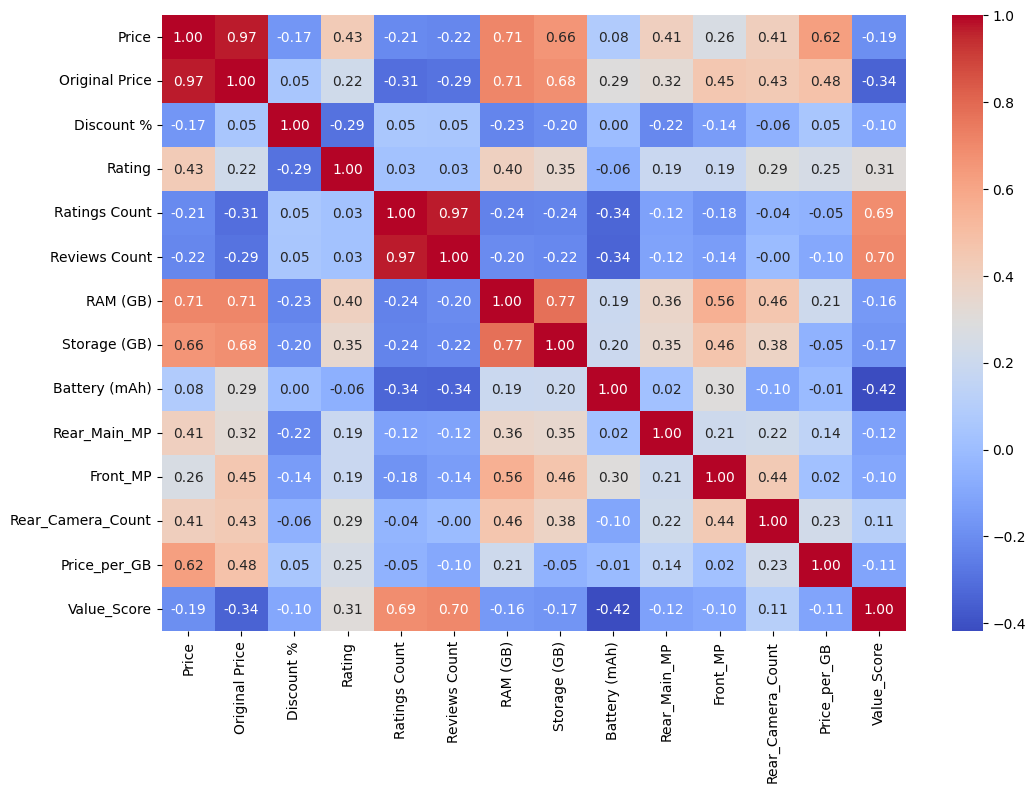

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.show()

In [42]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 841 entries, 0 to 983
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       841 non-null    object 
 1   Brand              841 non-null    object 
 2   Price              839 non-null    float64
 3   Original Price     645 non-null    float64
 4   Discount %         645 non-null    float64
 5   Rating             838 non-null    float64
 6   Ratings Count      838 non-null    float64
 7   Reviews Count      838 non-null    float64
 8   RAM (GB)           811 non-null    float64
 9   Storage (GB)       841 non-null    float64
 10  Rear Camera (MP)   841 non-null    object 
 11  Front Camera (MP)  699 non-null    object 
 12  Battery (mAh)      800 non-null    float64
 13  Rear_Main_MP       841 non-null    float64
 14  Front_MP           699 non-null    float64
 15  Rear_Camera_Count  841 non-null    int64  
 16  Price_per_GB       839 non-null

In [47]:
# Saving Cleaned Dataset
df_clean.to_csv(
    "mobile_phones_cleaned.csv",
    index=False
)